## 1. What this notebook computes

The author asked that two hypotheses be investigated: that dirac16complex
(Hypothesis) and dirac16complex00 (Hypothesis00) provide a possible physical
mechanism for a time-varying dark-energy and/or dark-matter equation of state. The
Revision record has investigated them, in the folders
`Revision/dark_sector/dirac16complex` and `Revision/dark_sector/dirac16complex00`.
This notebook reads the committed outputs and reports of that record and reproduces
its key numbers, each one checked against its record file and check:

- the observer identities $w_{\rm eff}(A) = w_{\rm eff}(B) = X/E$ and
  $w_{\rm eff}(C) = X/E - 1$, tested on the computed Kohn-Sham history, together
  with the energy balance $dE/da_4 = -3X$;
- the Kohn-Sham gas of dirac16complex: radiation-like, $X/E$ rising toward $1/3$,
  and its CPL tangents (small, thawing sign);
- the massive bulk band, which shows the dark-matter-like fall from about $1/3$
  toward 0, and the brane band, which does not;
- the condensate: its constant ratio $p/\rho = u/(2 + u)$ with $u = \lambda S/m$, and
  the value of $u$ CHOSEN to give the Unite constant $w = -0.764$;
- mixtures of the gas with a condensate: freezing, never the Unite slope;
- the models M2 to M5 of dirac16complex00: their tangents and fits against the
  Unite CPL line, every tuned parameter labelled CHOSEN, and the crossing of
  $w = -1$, which happens only with a ghost-like component.

It draws five figures and needs no Rust. Units: $H = m = 1$, as in the record.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 22b (The dark-sector hypotheses: what the Revision record finds) is the file
`Revision/textbook/notebooks/22b_dark_sector.ipynb` of the repository Dirac_claude. It
reads the committed outputs and reports of the Revision dark-sector record for
dirac16complex and dirac16complex00 and reproduces their key numbers: the observer
identities w_eff(A) = w_eff(B) = X/E and w_eff(C) = X/E - 1 on the Kohn-Sham history, the
radiation-like band of the Kohn-Sham gas and its CPL tangents, the dark-matter-like law
of the massive bulk band, the condensate ratio, the gas and condensate mixtures, and the
models M2 to M5 of dirac16complex00 against the Unite CPL values, every tuned parameter
labelled CHOSEN. Every reproduced number is checked against its record file and check,
and five teaching figures are drawn. It needs a computer with Windows 11, macOS or Linux,
an internet connection for the installation, the program Git, and Python 3.12 or newer
(the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy and matplotlib; the other packages run Jupyter, the program that
shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 22b_dark_sector.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 15 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 22b_dark_sector.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
22b_dark_sector.ipynb` (in the same folder, without running the cells again) to read the
printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/22b.captions.json`
- `Revision/textbook/figures/22b_1_gas_three_definitions.png`
- `Revision/textbook/figures/22b_2_bulk_and_brane_bands.png`
- `Revision/textbook/figures/22b_3_condensate_ratio.png`
- `Revision/textbook/figures/22b_4_mixtures_against_unite.png`
- `Revision/textbook/figures/22b_5_models_against_unite.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 28 CHECKS PASSED (notebook 22b)

and the notebook must show 5 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/22b_dark_sector.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4. If the environment is active and the message stays, the programs
  jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
  programs (`python -m jupyter` does not help then: it has to find the same programs).
  Start them through Python itself, in the folder of the notebook: the first command
  below does what `jupyter lab` does, the second what the headless command does:

      python -m jupyterlab 22b_dark_sector.ipynb
      python -m nbconvert --execute --inplace 22b_dark_sector.ipynb

- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 22b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 22b (The dark-sector hypotheses: what the Revision record finds) is the file
# Revision/textbook/notebooks/22b_dark_sector.ipynb of the repository Dirac_claude. It
# reads the committed outputs and reports of the Revision dark-sector record for
# dirac16complex and dirac16complex00 and reproduces their key numbers: the observer
# identities w_eff(A) = w_eff(B) = X/E and w_eff(C) = X/E - 1 on the Kohn-Sham history,
# the radiation-like band of the Kohn-Sham gas and its CPL tangents, the dark-matter-like
# law of the massive bulk band, the condensate ratio, the gas and condensate mixtures,
# and the models M2 to M5 of dirac16complex00 against the Unite CPL values, every tuned
# parameter labelled CHOSEN. Every reproduced number is checked against its record file
# and check, and five teaching figures are drawn. It needs a computer with Windows 11,
# macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 22b_dark_sector.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 15
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 22b_dark_sector.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 22b_dark_sector.ipynb (in the same folder, without running the cells again) to read the
# printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/22b.captions.json
# - Revision/textbook/figures/22b_1_gas_three_definitions.png
# - Revision/textbook/figures/22b_2_bulk_and_brane_bands.png
# - Revision/textbook/figures/22b_3_condensate_ratio.png
# - Revision/textbook/figures/22b_4_mixtures_against_unite.png
# - Revision/textbook/figures/22b_5_models_against_unite.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 28 CHECKS PASSED (notebook 22b)
#
# and the notebook must show 5 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/22b_dark_sector.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4. If the environment is active and the message stays, the programs
#   jupyter-lab and jupyter-nbconvert are not in the folders where the terminal looks for
#   programs (python -m jupyter does not help then: it has to find the same programs).
#   Start them through Python itself, in the folder of the notebook: the first command
#   below does what jupyter lab does, the second what the headless command does:
#     python -m jupyterlab 22b_dark_sector.ipynb
#     python -m nbconvert --execute --inplace 22b_dark_sector.ipynb
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "22b"  # this notebook: chapter 22, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 22b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Equation of state** $w$: a pressure divided by an energy density. **Observer**:
  someone who, like us, measures only the three space directions $x_1, x_2, x_3$
  and the time $x_4$.
- **$\rho_4$**: the energy density that this observer assigns to 3-space. It is NOT
  fixed by the field equations; the record states three definitions: (A) the extra
  times are closed with a fixed coordinate period, $\rho_4 \propto E e^{-3a_4}$;
  (B) $\rho_4$ per unit extra-time coordinate volume, $\rho_4 \propto E e^{-3a_4}$;
  (C) $\rho_4$ per unit proper 7-volume, $\rho_4 \propto E$. This is an
  ASSUMPTION about the observer.
- **$E, P_3, P_t$**: the energy and the integrated pressures of 3-space and of the
  extra times of one state; **$X = P_3 - P_t$**.
- **$w_{\rm eff}$**: the equation of state the observer infers from how fast
  $\rho_4$ thins out, $w_{\rm eff} = -1 - \frac{1}{3}\,d\ln\rho_4/d\ln a$, with the
  observer's scale factor $a = e^{a_4 - a_{4,\rm today}}$.
- **Radiation-like**: $w_{\rm eff} = 1/3$; **dust-like** (dark-matter-like):
  $w_{\rm eff} = 0$; **cosmological-constant-like**: $w = -1$; **phantom**:
  $w < -1$.
- **CPL**: $w(a) = w_0 + w_a(1 - a)$. **Tangent**: $w_0 = w(1)$ and
  $w_a = -dw/da$ at $a = 1$. **Fit**: the least-squares straight line in $1 - a$
  over a range of $a$. **Thawing**: $w_a < 0$; **freezing**: $w_a > 0$.
- **Unite values**: the supernova fits quoted by the record, $w = -0.764$ (constant
  $w$) and $(w_0, w_a) = (-0.861, -0.60)$.
- **CHOSEN**: a parameter fixed so that a model reproduces a Unite number; that
  number is then an input, NOT a prediction.
- **Ghost-like component**: a component of negative classical energy.

## 4. The physical and mathematical situation

The author's metric has the 3-space scale factor $e^{a_4}\sin^{1/6}z$ and the
extra-time scale factor $e^{-a_4}\sin^{1/6}z$: as $a_4$ grows, 3-space inflates and
the three extra times $x_5, x_6, x_7$ deflate exponentially. The proper 7-volume
element is $\cos z$, independent of $a_4$, and for a homogeneous source the
conservation law gives exactly (record `derivation-checks.json`)
$$\frac{dE}{da_4} = -3X, \qquad X = P_3 - P_t .$$
With $\rho_4 \propto E e^{-3(1-s)a_4}$ ($s = 0$ for A and B, $s = 1$ for C) and
$d\ln a = da_4$:
$$w_{\rm eff} = -1 - \frac{1}{3}\left(\frac{1}{E}\frac{dE}{da_4} - 3(1 - s)\right)
= -1 + \frac{X}{E} + 1 - s = \frac{X}{E} - s .$$
The Kohn-Sham states are instantaneous ground states along the PRESCRIBED
BACKGROUND $a_4 = AHx_4$ (a test field without back-reaction), with the ASSUMED Z2
brane. The models of dirac16complex00 are adiabatic (WKB) gases of plane-wave modes,
an APPROXIMATION that the record measures with a second implementation.

## 5. The records

The next cell loads the modules, reads the six check reports of the dark-sector
record and checks that every one of their checks is PASS, then reads the table of
the Kohn-Sham history and the four output files whose numbers the later cells
reproduce.

In [2]:
import csv  # reads the CSV tables of the Revision record
from fractions import Fraction  # exact fractions such as -382/441

import numpy as np  # arrays of numbers and their arithmetic

D16 = "Revision/dark_sector/dirac16complex"  # the record of dirac16complex
D00 = "Revision/dark_sector/dirac16complex00"  # the record of dirac16complex00
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order


def read_json(relative):
    """Read a JSON record of the repository into a Python dictionary."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


REPORTS = {"derive": f"{D16}/reports/derivation-checks.json",
           "history": f"{D16}/reports/ks-history-run.json",
           "eos": f"{D16}/reports/eos-checks.json",
           "independent": f"{D16}/reports/independent-checks.json",
           "derive00": f"{D00}/reports/python-derive-eos.json",
           "numerics00": f"{D00}/reports/python-independent-numerics.json"}
EXPECTED = {"derive": 30, "history": 5, "eos": 13, "independent": 9,
            "derive00": 49, "numerics00": 28}  # the checks each report holds
for key, relative in REPORTS.items():
    entries = read_json(relative)["checks"]
    passed = [entry for entry in entries if entry["verdict"] == "PASS"]
    say(f"{relative}: {len(passed)} of {len(entries)} checks PASS")
    check(len(passed) == len(entries) == EXPECTED[key],
          f"all {EXPECTED[key]} checks of the report {key} are PASS",
          record=f"{relative}, all checks")

with open(repository_file(f"{D16}/outputs/eos-history.csv"), newline="",
          encoding="utf-8") as handle:
    rows = list(csv.DictReader(handle))
COLUMNS = ["N", "a4", "E", "P3", "Pt", "dw_eff_da4"]
SERIES = {}  # series name -> {column name: numpy array over the slices}
for name in sorted({row["series"] for row in rows}):
    mine = [row for row in rows if row["series"] == name]
    SERIES[name] = {column: np.array([float(row[column]) for row in mine])
                    for column in COLUMNS}
GAS = [name for name in SERIES if SERIES[name]["N"][0] in (136, 688)]
summary = read_json(f"{D16}/outputs/eos-summary.json")
free_gas = read_json(f"{D16}/outputs/independent-free-gas.json")
theory00 = read_json(f"{D00}/eos-theory.json")
numerics00 = read_json(f"{D00}/results/independent-numerics.json")
say(f"{len(rows)} rows read: {len(SERIES)} series, {len(GAS)} of them with "
    "N = 136 or 688")
check(all(len(SERIES[name]["a4"]) == 41 for name in SERIES)
      and all(np.all(np.diff(SERIES[name]["a4"]) > 0) for name in SERIES),
      "every series has 41 slices in increasing order of a4")

Revision/dark_sector/dirac16complex/reports/derivation-checks.json: 30 of 30 checks PASS
PASS all 30 checks of the report derive are PASS
     reproduces Revision/dark_sector/dirac16complex/reports/derivation-checks.json, all
    checks
Revision/dark_sector/dirac16complex/reports/ks-history-run.json: 5 of 5 checks PASS
PASS all 5 checks of the report history are PASS
     reproduces Revision/dark_sector/dirac16complex/reports/ks-history-run.json, all
    checks
Revision/dark_sector/dirac16complex/reports/eos-checks.json: 13 of 13 checks PASS
PASS all 13 checks of the report eos are PASS
     reproduces Revision/dark_sector/dirac16complex/reports/eos-checks.json, all checks
Revision/dark_sector/dirac16complex/reports/independent-checks.json: 9 of 9 checks PASS
PASS all 9 checks of the report independent are PASS
     reproduces Revision/dark_sector/dirac16complex/reports/independent-checks.json, all
    checks
Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json: 49 of 4

## 6. The observer's equation of state on the Kohn-Sham gas

The next cell tests the energy balance $dE/da_4 = -3X$ on the computed history
(fourth-order differences of $E$ against $X$ from the solver's integrals), then
computes $w_{\rm eff}$ directly from its definition, by differentiating
$\ln\rho_4$ for the definitions A, B and C, and compares with $X/E$ and $X/E - 1$.
It checks the band of $X/E$ over all gas series and that $X/E$ rises with $a_4$,
and draws the histories (Figure 1).

RESULT largest |dE/da4 + 3X|/max|E| over the 10 gas series = 1.235e-07
PASS the energy balance dE/da4 = -3X on the data
     reproduces Revision/dark_sector/dirac16complex/reports/eos-checks.json, check
    conservation_dE_da4_equals_minus_3X
RESULT largest |w_eff(A, B) - X/E| from the dilution = 1.7e-08
RESULT largest |w_eff(C) - (X/E - 1)| from the dilution = 1.7e-08
PASS w_eff(A) = w_eff(B) = X/E and w_eff(C) = X/E - 1 on the data
     reproduces Revision/dark_sector/dirac16complex/reports/derivation-checks.json,
    checks w_eff_A_equals_X_over_E and w_eff_C_equals_X_over_E_minus_1
RESULT X/E of N688_lam0 at a4 = 0 and a4 = 2 = 0.2929, 0.3183
RESULT X/E over all gas series, smallest and largest = 0.292893, 0.328105
RESULT w_eff(C) over all gas series, smallest and largest = -0.707107, -0.671895
PASS the gas is radiation-like: X/E in [0.292893, 0.328105]
     reproduces Revision/dark_sector/dirac16complex/reports/eos-checks.json, check
    gas_radiation_like_band
PASS X/E rises with

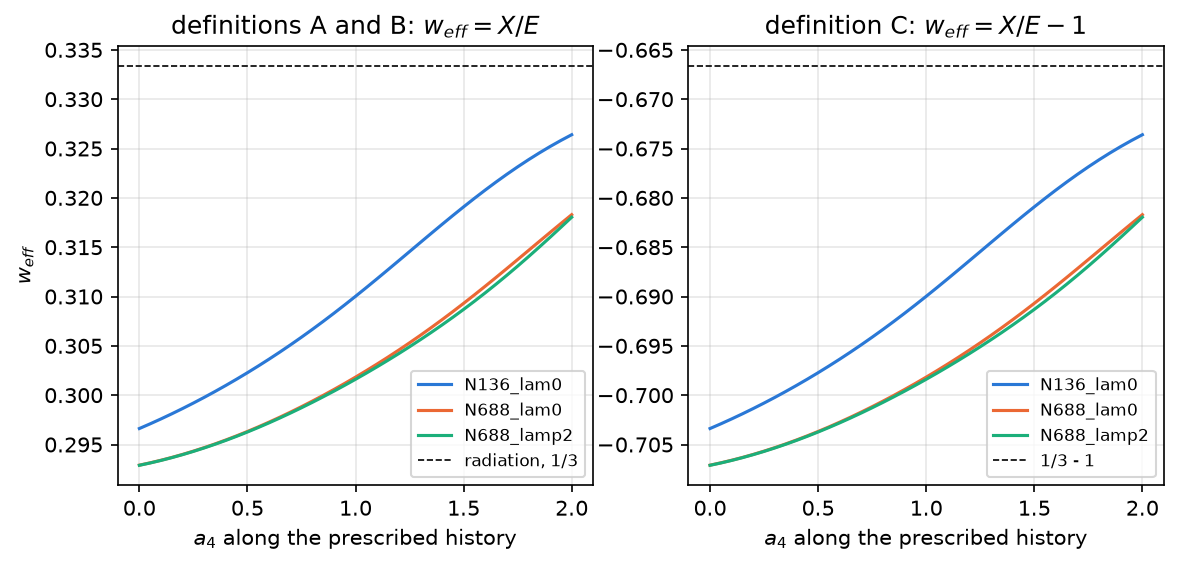

Figure 22b.1 saved as Revision/textbook/figures/22b_1_gas_three_definitions.png


In [3]:
def x_over_e(name):
    """X/E = (P3 - Pt)/E of one series at its 41 slices."""
    return (SERIES[name]["P3"] - SERIES[name]["Pt"]) / SERIES[name]["E"]


gas = SERIES["N688_lam0"]  # the gas of N = 688 quanta with lambda = 0
a4, E = gas["a4"], gas["E"]
X = gas["P3"] - gas["Pt"]
h = a4[1] - a4[0]  # the step 0.05 between two slices


def derivative(f):
    """df/da4 at the slices 2 to 38: fourth-order central differences."""
    return (f[:-4] - 8 * f[1:-3] + 8 * f[3:-1] - f[4:]) / (12 * h)


worst = 0.0  # the largest relative violation of dE/da4 = -3X
for name in GAS:
    E_n = SERIES[name]["E"]
    X_n = SERIES[name]["P3"] - SERIES[name]["Pt"]
    violation = np.max(np.abs(derivative(E_n) + 3 * X_n[2:-2])) / np.max(np.abs(E_n))
    worst = max(worst, violation)
report("largest |dE/da4 + 3X|/max|E| over the 10 gas series", f"{worst:.3e}")
check(f"{worst:.3e}" == "1.235e-07", "the energy balance dE/da4 = -3X on the data",
      record=f"{D16}/reports/eos-checks.json, "
             "check conservation_dE_da4_equals_minus_3X")

rho4_AB = E * np.exp(-3 * a4)  # definitions A and B: rho4 ~ E e^(-3 a4)
rho4_C = E  # definition C: rho4 ~ E
w_AB = -1 - derivative(np.log(rho4_AB)) / 3  # -1 - (1/3) d ln rho4/d ln a
w_C = -1 - derivative(np.log(rho4_C)) / 3
error_AB = np.max(np.abs(w_AB - (X / E)[2:-2]))
error_C = np.max(np.abs(w_C - (X / E - 1)[2:-2]))
report("largest |w_eff(A, B) - X/E| from the dilution", f"{error_AB:.1e}")
report("largest |w_eff(C) - (X/E - 1)| from the dilution", f"{error_C:.1e}")
check(max(error_AB, error_C) < 1e-7,
      "w_eff(A) = w_eff(B) = X/E and w_eff(C) = X/E - 1 on the data",
      record=f"{D16}/reports/derivation-checks.json, checks "
             "w_eff_A_equals_X_over_E and w_eff_C_equals_X_over_E_minus_1")

ratios = np.concatenate([x_over_e(name) for name in GAS])
report("X/E of N688_lam0 at a4 = 0 and a4 = 2", f"{X[0] / E[0]:.4f}, "
       f"{X[-1] / E[-1]:.4f}")
report("X/E over all gas series, smallest and largest",
       f"{ratios.min():.6f}, {ratios.max():.6f}")
report("w_eff(C) over all gas series, smallest and largest",
       f"{ratios.min() - 1:.6f}, {ratios.max() - 1:.6f}")
check(f"{ratios.min():.6f}" == "0.292893" and f"{ratios.max():.6f}" == "0.328105",
      "the gas is radiation-like: X/E in [0.292893, 0.328105]",
      record=f"{D16}/reports/eos-checks.json, check gas_radiation_like_band")
check(all(np.all(np.diff(x_over_e(name)) > 0) for name in GAS),
      "X/E rises with a4 in every gas series (toward 1/3, not toward 0)",
      record=f"{D16}/reports/eos-checks.json, "
             "check gas_X_over_E_rises_toward_one_third")

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
for colour, name in zip(PALETTE, ["N136_lam0", "N688_lam0", "N688_lamp2"]):
    left.plot(SERIES[name]["a4"], x_over_e(name), color=colour, label=name)
    right.plot(SERIES[name]["a4"], x_over_e(name) - 1, color=colour, label=name)
left.axhline(1 / 3, color="black", linestyle="--", linewidth=0.8,
             label="radiation, 1/3")
right.axhline(-2 / 3, color="black", linestyle="--", linewidth=0.8,
              label="1/3 - 1")
left.set_title("definitions A and B: $w_{eff} = X/E$")
right.set_title("definition C: $w_{eff} = X/E - 1$")
for ax in (left, right):
    ax.set_xlabel("$a_4$ along the prescribed history")
    ax.legend(fontsize=8)
left.set_ylabel("$w_{eff}$")
save_figure(fig, "gas_three_definitions",
            "The equation of state $w_{eff}$ that a 3-space observer infers from "
            "the thinning of the Kohn-Sham gas of dirac16complex along the "
            "prescribed history, for three recorded series; horizontal axis $a_4$ "
            "from 0 to 2 (one unit is one e-fold of inflation of 3-space and of "
            "deflation of the extra times), vertical axis $w_{eff}$ (a pure "
            "number). Left, definitions A and B of the observer density: "
            "$w_{eff} = X/E$ rises from about 0.29 toward the radiation value 1/3 "
            "(dashed). Right, definition C: the same curves moved down by exactly "
            "1, between about $-0.71$ and $-0.67$, never near $-1$. The observer "
            "assumption alone decides whether the same gas reads as radiation or "
            "as dark energy.")

## 7. The CPL tangents of the gas

The observer's scale factor is $a = e^{a_4 - a_{4,\rm today}}$, so at $a = 1$ the
slope $dw/da$ equals $dw/da_4$ and the tangent is $w_0 = w(a_{4,\rm today})$,
$w_a = -dw_{\rm eff}/da_4$. The next cell reads $dw_{\rm eff}/da_4$ from the record's
table at the four values of $a_{4,\rm today}$ that the record uses, prints the
tangents of the gas N688_lam0 under definition C, and checks them and the range of
the tangents of all gas series.

In [4]:
TODAY = [0.5, 1.0, 1.5, 2.0]  # the four choices of a4,today of the record
index = [int(round(t / h)) for t in TODAY]  # their positions in the slice list
recorded = {entry["series"]: entry for entry in summary["series"]}
say("a4,today   w0 under C   wa (every definition)")
differences = []
for t, i, entry in zip(TODAY, index, recorded["N688_lam0"]["cplTangent"]):
    w0 = X[i] / E[i] - 1  # w_eff(C) today
    wa = -gas["dw_eff_da4"][i]  # w_a = -dw/da at a = 1, and da = da4 there
    say(f"{t:8.1f}   {w0:10.4f}   {wa:12.5f}")
    differences += [abs(w0 - entry["w_eff_C"]["w0"]), abs(wa - entry["w_eff_C"]["wa"])]
check(max(differences) < 1e-12, "the CPL tangents of N688_lam0",
      record=f"{D16}/outputs/eos-summary.json, key cplTangent of N688_lam0")

tangents = [-SERIES[name]["dw_eff_da4"][i] for name in GAS for i in index]
report("tangent wa of every gas series, smallest and largest",
       f"{min(tangents):.6f}, {max(tangents):.6f}")
check(f"{min(tangents):.6f}" == "-0.020523" and f"{max(tangents):.6f}" == "-0.008894"
      and f"{ratios.min() - 1:.6f}" == "-0.707107"
      and f"{ratios.max() - 1:.6f}" == "-0.671895",
      "every gas tangent wa is negative (thawing sign) and far below 0.60",
      record=f"{D16}/reports/eos-checks.json, check gas_cpl_thawing_sign_small")

a4,today   w0 under C   wa (every definition)
     0.5      -0.7037       -0.00905
     1.0      -0.6982       -0.01292
     1.5      -0.6907       -0.01701
     2.0      -0.6817       -0.01775
PASS the CPL tangents of N688_lam0
     reproduces Revision/dark_sector/dirac16complex/outputs/eos-summary.json, key
    cplTangent of N688_lam0
RESULT tangent wa of every gas series, smallest and largest = -0.020523, -0.008894
PASS every gas tangent wa is negative (thawing sign) and far below 0.60
     reproduces Revision/dark_sector/dirac16complex/reports/eos-checks.json, check
    gas_cpl_thawing_sign_small


## 8. The bulk band and the brane band

The occupied levels of the computed ground states lie on the brane band, which is
massless at zero 3-momentum. The record's independent free-gas computation also
follows one level of the massive bulk band (odd brane parity) and one brane-band
level of the same 3-momentum shell over $a_4$ from $-3$ to $4$. The next cell reads
their $w_{\rm eff}(A)$, checks the dark-matter-like fall of the bulk level and the
radiation-like value of the brane level, and draws both with the gas (Figure 2).

RESULT w_eff(A) of the bulk level at a4 = -3 and a4 = 4 = 0.239626, 2.268e-03
RESULT ratio w(4)/w(3.75) of the bulk level = 0.765177
RESULT w_eff(A) of the brane level, smallest and largest = 0.291594, 0.333275
PASS the bulk level falls from 0.239626 to 2.268e-03 (dark-matter-like)
     reproduces Revision/dark_sector/dirac16complex/reports/independent-checks.json,
    check bulk_band_dark_matter_law
PASS the brane level stays between 0.291594 and 0.333275 (radiation-like)
     reproduces Revision/dark_sector/dirac16complex/reports/independent-checks.json,
    check brane_band_radiation_law


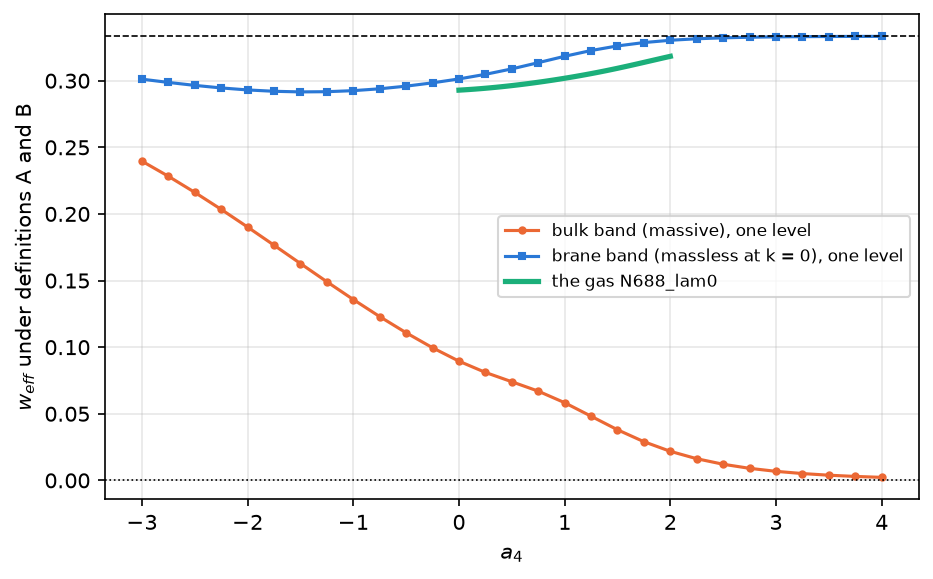

Figure 22b.2 saved as Revision/textbook/figures/22b_2_bulk_and_brane_bands.png


In [5]:
bulk = free_gas["bulkBand_n2_1"]  # the lowest massive (odd-parity) level, shell 1
brane = free_gas["braneBand_n2_1"]  # the brane-band level of the same shell
a4_band = np.array([point["a4"] for point in bulk])
w_bulk = np.array([point["w_eff_A_B"] for point in bulk])
w_brane = np.array([point["w_eff_A_B"] for point in brane])
report("w_eff(A) of the bulk level at a4 = -3 and a4 = 4",
       f"{w_bulk[0]:.6f}, {w_bulk[-1]:.3e}")
report("ratio w(4)/w(3.75) of the bulk level", f"{w_bulk[-1] / w_bulk[-2]:.6f}")
report("w_eff(A) of the brane level, smallest and largest",
       f"{w_brane.min():.6f}, {w_brane.max():.6f}")
check(a4_band[0] == -3 and a4_band[-1] == 4 and np.all(np.diff(w_bulk) < 0)
      and f"{w_bulk[0]:.6f}" == "0.239626" and f"{w_bulk[-1]:.3e}" == "2.268e-03",
      "the bulk level falls from 0.239626 to 2.268e-03 (dark-matter-like)",
      record=f"{D16}/reports/independent-checks.json, check bulk_band_dark_matter_law")
check(f"{w_brane.min():.6f}" == "0.291594" and f"{w_brane.max():.6f}" == "0.333275",
      "the brane level stays between 0.291594 and 0.333275 (radiation-like)",
      record=f"{D16}/reports/independent-checks.json, check brane_band_radiation_law")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(a4_band, w_bulk, "o-", color=PALETTE[1], markersize=3,
        label="bulk band (massive), one level")
ax.plot(a4_band, w_brane, "s-", color=PALETTE[0], markersize=3,
        label="brane band (massless at k = 0), one level")
ax.plot(a4, X / E, color=PALETTE[2], linewidth=2.5, label="the gas N688_lam0")
ax.axhline(1 / 3, color="black", linestyle="--", linewidth=0.8)
ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8)
ax.set_xlabel("$a_4$")
ax.set_ylabel("$w_{eff}$ under definitions A and B")
ax.legend(fontsize=8)
save_figure(fig, "bulk_and_brane_bands",
            "Which quanta of dirac16complex behave like dark matter. Horizontal "
            "axis $a_4$ from $-3$ to 4, vertical axis $w_{eff}$ under definitions "
            "A and B (a pure number). Orange: one level of the massive bulk band "
            "falls from 0.24 toward the dust value 0 (dotted), the "
            "dark-matter-like law. Blue: a brane-band level of the same shell "
            "tends to the radiation value 1/3 (dashed). Green, thick: the computed "
            "Kohn-Sham gas, which fills only the brane band and is radiation-like. "
            "The computed ground states do not populate the bulk band.")

## 9. The condensate

A homogeneous condensate is an exact solution of both fields, with
$\rho = mS + \lambda S^2/2$ and $p_3 = p_t = p_8 = \lambda S^2/2$, all constant.
So $X = 0$: $w_{\rm eff} = 0$ under A and B (dust-like), $-1$ under C. Its ratio is
$p/\rho = u/(2 + u)$ with $u = \lambda S/m$. The next cell computes, with exact
fractions, the value $u = -382/441$ that the record CHOSE so that the ratio equals
$-0.764$, checks the phantom window, and draws the ratio (Figure 3).

RESULT the ratio u/(2 + u) at u = -382/441 = -191/250 = -0.764
RESULT rho/(m S) = 1 + u/2 = 250/441 = 0.566893424036
PASS the condensate ratio is -0.764 at u = -382/441 (one CHOSEN parameter)
     reproduces Revision/dark_sector/dirac16complex/reports/derivation-checks.json, check
    condensate_ratio_equal_unite_constant_w
PASS the ratio is below -1 exactly for -2 < u < -1
     reproduces Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json,
    check condensate_phantom_interval


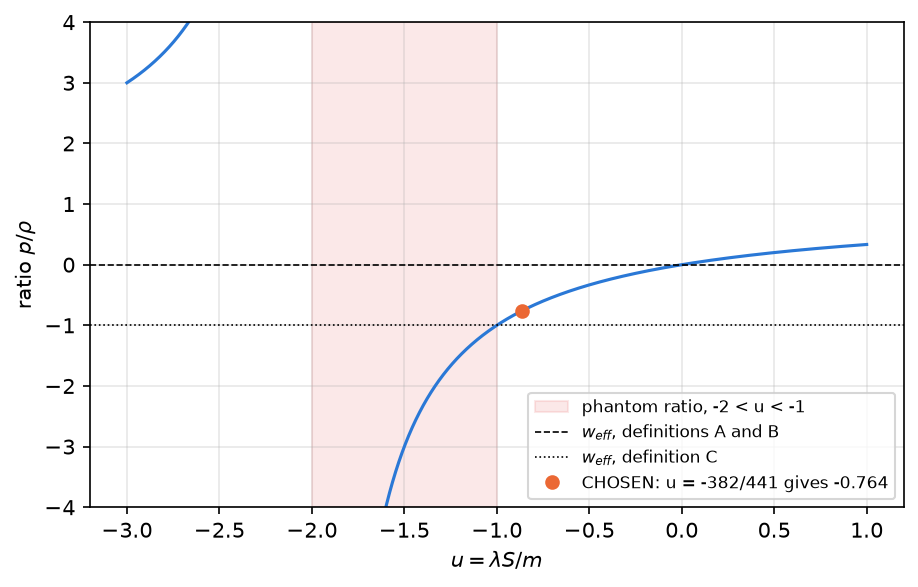

Figure 22b.3 saved as Revision/textbook/figures/22b_3_condensate_ratio.png


In [6]:
u = Fraction(-382, 441)  # lambda S/m, CHOSEN so that the ratio is -0.764
ratio = u / (2 + u)  # p/rho = (lambda S^2/2)/(m S + lambda S^2/2) = u/(2 + u)
density = 1 + u / 2  # rho/(m S)
report("the ratio u/(2 + u) at u = -382/441", f"{ratio} = {float(ratio)}")
report("rho/(m S) = 1 + u/2", f"{density} = {float(density):.12f}")
check(ratio == Fraction(-764, 1000)
      and abs(float(u) - summary["condensate"]["u_for_ratio_minus_0p764"]) < 1e-12,
      "the condensate ratio is -0.764 at u = -382/441 (one CHOSEN parameter)",
      record=f"{D16}/reports/derivation-checks.json, "
             "check condensate_ratio_equal_unite_constant_w")

grid = np.linspace(-3.0, 1.0, 4001)
grid = grid[np.abs(grid + 2) > 1e-9]  # leave out the pole u = -2
below = grid / (2 + grid) < -1  # where the ratio is phantom
check(np.array_equal(below, (grid > -2) & (grid < -1)),
      "the ratio is below -1 exactly for -2 < u < -1",
      record=f"{D00}/reports/python-derive-eos.json, "
             "check condensate_phantom_interval")

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for part in (grid[grid < -2], grid[grid > -2]):
    ax.plot(part, part / (2 + part), color=PALETTE[0])
ax.axvspan(-2, -1, color=PALETTE[7], alpha=0.12, label="phantom ratio, -2 < u < -1")
ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8,
           label="$w_{eff}$, definitions A and B")
ax.axhline(-1.0, color="black", linestyle=":", linewidth=0.8,
           label="$w_{eff}$, definition C")
ax.plot([float(u)], [float(ratio)], "o", color=PALETTE[1],
        label="CHOSEN: u = -382/441 gives -0.764")
ax.set_ylim(-4.0, 4.0)
ax.set_xlabel("$u = \\lambda S/m$")
ax.set_ylabel("ratio $p/\\rho$")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "condensate_ratio",
            "The constant ratio $p/\\rho = u/(2 + u)$ of a homogeneous condensate "
            "against $u = \\lambda S/m$ (horizontal axis, a pure number; the "
            "ratio has a pole at $u = -2$). The orange point is the value "
            "$u = -382/441$ CHOSEN so that the ratio equals the Unite constant "
            "$w = -0.764$: one parameter for one number, not a prediction. The red "
            "band is the phantom window. The observer does not see this ratio: "
            "the dilution gives $w_{eff} = 0$ under A and B (dashed) and $-1$ "
            "under C (dotted), constant in time.")

## 10. Mixtures of the gas with a condensate

For a radiation-like gas ($X = E/3$, $E \propto 1/a$) plus a condensate ($X = 0$,
$E$ constant) with energy ratio $r = r_0/a$, the record derives exactly
$w_{\rm eff}(A) = \frac{1}{3}r/(1 + r)$, so $w_0 = r_0/(3(r_0 + 1))$ and
$w_a = r_0/(3(r_0 + 1)^2) > 0$: freezing. The next cell evaluates this law at the
$r_0$ CHOSEN for $w_{\rm eff}(C) = -0.861$ today, then mixes the computed gas
N688_lam0 with a condensate (today $a_{4,\rm today} = 2$), with the gas share CHOSEN
for $w_{\rm eff}(C) = -0.861$, and draws mixtures against the Unite line (Figure 4).

RESULT exact law: w0 under C and wa = -861/1000, 0.081037
PASS radiation plus condensate with w0(C) = -0.861 has wa = 0.081037 > 0
     reproduces Revision/dark_sector/dirac16complex/reports/derivation-checks.json, check
    mixture_C_matching_w0_unite
RESULT gas share today for w_eff(C) = -0.861 (CHOSEN) = 0.436703
RESULT w0 and wa of that mixture under C = -0.861, 0.067014
PASS the computed gas mixture with w0(C) = -0.861 is freezing, wa = 0.067014
     reproduces Revision/dark_sector/dirac16complex/reports/eos-checks.json, check
    mixture_C_w0_unite_has_positive_wa


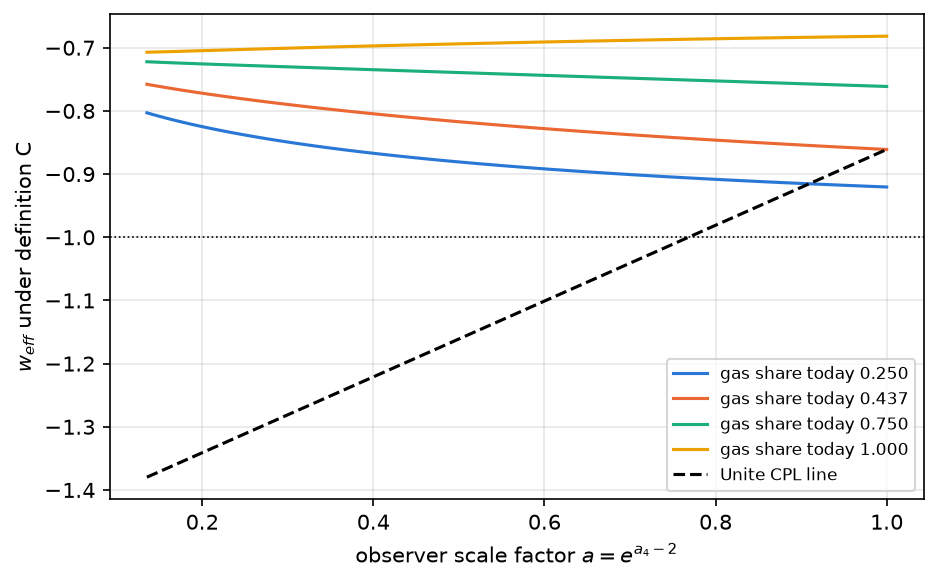

Figure 22b.4 saved as Revision/textbook/figures/22b_4_mixtures_against_unite.png


In [7]:
r0 = Fraction(417, 583)  # gas/condensate energy today, CHOSEN for w0(C) = -0.861
w0_exact = r0 / (3 * (r0 + 1)) - 1  # w_eff(C) today
wa_exact = r0 / (3 * (r0 + 1) ** 2)  # w_a of the exact law: positive (freezing)
report("exact law: w0 under C and wa", f"{w0_exact}, {float(wa_exact):.6f}")
check(w0_exact == Fraction(-861, 1000) and f"{float(wa_exact):.6f}" == "0.081037",
      "radiation plus condensate with w0(C) = -0.861 has wa = 0.081037 > 0",
      record=f"{D16}/reports/derivation-checks.json, "
             "check mixture_C_matching_w0_unite")


def mixture_w_C(share):
    """w_eff(C) of the gas N688_lam0 plus a condensate along the history; the gas
    has the energy share "share" today (a4 = 2)."""
    condensate = E[-1] * (1 - share) / share  # constant condensate energy
    return X / (E + condensate) - 1


share = 0.139 / (X[-1] / E[-1])  # CHOSEN: gives w_eff(C) = -0.861 today
w_mix = mixture_w_C(share)
# w_a = -dw/da4 at a4 = 2, one-sided fourth-order differences (as the record)
wa_mix = -(3 * w_mix[-5] - 16 * w_mix[-4] + 36 * w_mix[-3] - 48 * w_mix[-2]
           + 25 * w_mix[-1]) / (12 * h)
recorded_mix = summary["mixture_C_w0_minus_0p861"]
report("gas share today for w_eff(C) = -0.861 (CHOSEN)", f"{share:.6f}")
report("w0 and wa of that mixture under C", f"{w_mix[-1]:.3f}, {wa_mix:.6f}")
check(abs(share - recorded_mix["gas_fraction_today"]) < 1e-12
      and abs(wa_mix - recorded_mix["wa"]) < 1e-10 and wa_mix > 0,
      "the computed gas mixture with w0(C) = -0.861 is freezing, wa = 0.067014",
      record=f"{D16}/reports/eos-checks.json, check mixture_C_w0_unite_has_positive_wa")

a_obs = np.exp(a4 - 2.0)  # the observer scale factor, a = 1 today (a4 = 2)
fig, ax = plt.subplots(figsize=(7.0, 4.2))
for colour, part in zip(PALETTE, [0.25, share, 0.75, 1.0]):
    ax.plot(a_obs, mixture_w_C(part), color=colour,
            label=f"gas share today {part:.3f}")
ax.plot(a_obs, -0.861 - 0.60 * (1 - a_obs), "k--", label="Unite CPL line")
ax.axhline(-1.0, color="black", linestyle=":", linewidth=0.8)
ax.set_xlabel("observer scale factor $a = e^{a_4 - 2}$")
ax.set_ylabel("$w_{eff}$ under definition C")
ax.legend(fontsize=8)
save_figure(fig, "mixtures_against_unite",
            "Mixtures of the computed Kohn-Sham gas N688_lam0 with a condensate, "
            "under definition C, against the observer scale factor $a$ "
            "(horizontal axis, $a = 1$ today, taken at $a_4 = 2$); vertical axis "
            "$w_{eff}$ (a pure number). Each coloured curve has another gas "
            "share today; the share 0.437 is CHOSEN so that $w_{eff} = -0.861$ "
            "today. Every curve that contains condensate falls toward the "
            "condensate value $-1$ (dotted) as $a$ grows: freezing, $w_a > 0$; "
            "the pure gas (share 1) rises only slightly. The Unite CPL line "
            "(dashed) rises steeply instead: $w_a = -0.60$. No share gives the "
            "Unite slope.")

## 11. The models M2 to M5 of dirac16complex00

Each component of an adiabatic (WKB) gas of dirac16complex00 has an energy
density $\rho_i$ and $\varepsilon_i = (k^2/a^2 + q^2a^2)/(3\omega_i^2) \ge 0$ with
$\omega^2 = m^2 + k^2/a^2 - q^2a^2$; a mixture has
$w_{\rm eff}(C) = \sum_i\varepsilon_i\rho_i/\sum_i\rho_i - 1$. The record's models
(normalised to total energy 1 at $a = 1$): M2 a good-sector gas ($q = 0$), M3 one
extra-time mode ($k = 0$), M4 a condensate plus an extra-time mode, M5 the same plus
a GHOST-LIKE component of negative energy $-G/a$. The next cell rebuilds them,
checks their tangents, the M5 fit, the crossings of $-1$ and the agreement of the
field-equation implementation B, and draws them against the Unite line (Figure 5).

RESULT M2 tangent (w0, wa) under C = (-0.861000, 0.162074)
PASS the tangent of M2
     reproduces Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json,
    check M2_tangent_exact
RESULT M3 tangent (w0, wa) under C = (-0.861000, -0.393926)
PASS the tangent of M3
     reproduces Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json,
    check M3_tangent_exact
RESULT M4 tangent (w0, wa) under C = (-0.861000, -0.600000)
PASS the tangent of M4
     reproduces Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json,
    check M4_tangent_equals_unite
RESULT M5 least-squares fit over a in [1/2, 1] = (-0.861000, -0.600000)
PASS the M5 fit equals the Unite pair (by construction)
     reproduces Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json,
    check M5_fit_equals_unite
RESULT M5 crosses w = -1 at a = 0.77909966367
RESULT the same crossing from the field equation (implementation B) = 0.77905405
RESULT lowest w_eff(C) of M4 for a 

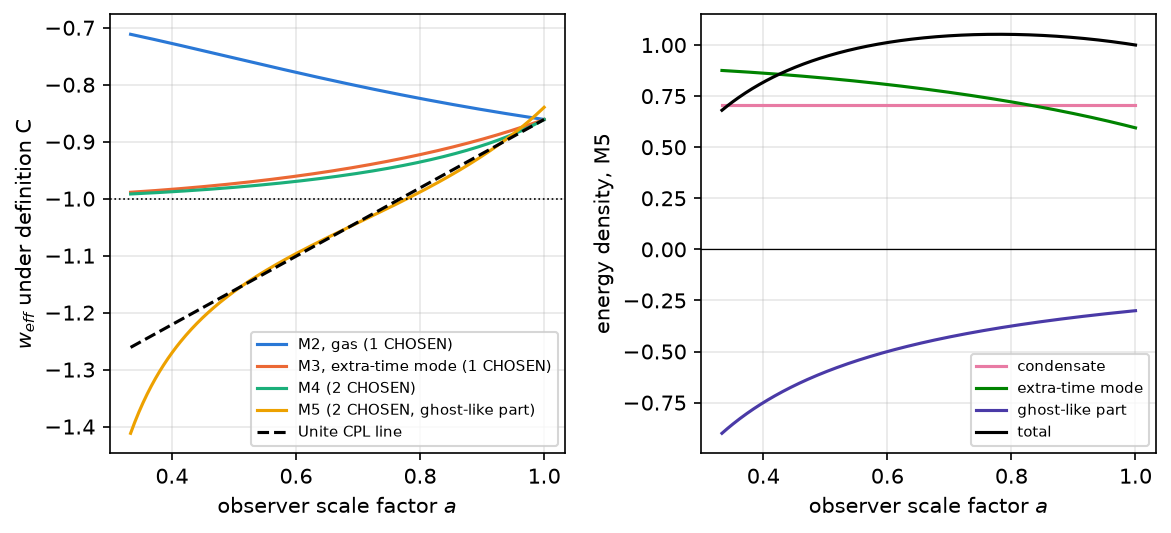

Figure 22b.5 saved as Revision/textbook/figures/22b_5_models_against_unite.png


In [8]:
def model(a, components):
    """The total energy density and the sum of eps_i rho_i of a WKB model at a
    (a number or an array).  Each component is (kind, weight at a = 1, s)."""
    a = np.asarray(a, dtype=float)
    rho_total, eps_rho = np.zeros_like(a), np.zeros_like(a)
    for kind, weight, s in components:
        if kind == "condensate":  # rho constant, eps = 0
            rho, eps = weight + 0 * a, 0 * a
        elif kind == "kmode":  # q = 0 and s = k^2/(k^2 + m^2) at a = 1
            r = s / (1 - s)  # k^2/m^2
            rho = weight * np.sqrt((r / a**2 + 1) / (r + 1))  # omega(a)/omega(1)
            eps = (r / a**2) / (3 * (r / a**2 + 1))
        elif kind == "qmode":  # k = 0 and s = q^2/m^2 at a = 1
            rho = weight * np.sqrt((1 - s * a**2) / (1 - s))
            eps = s * a**2 / (3 * (1 - s * a**2))
        else:  # "ghost": massless modes of NEGATIVE classical energy
            rho, eps = -weight / a, 1 / 3 + 0 * a
        rho_total = rho_total + rho
        eps_rho = eps_rho + eps * rho
    return rho_total, eps_rho


def w_model(a, components):
    """w_eff under definition C: sum eps_i rho_i / sum rho_i - 1."""
    rho_total, eps_rho = model(a, components)
    return eps_rho / rho_total - 1


def tangent(components, d=1e-3):
    """CPL tangent w0 = w(1), wa = -dw/da at a = 1 (fourth-order differences)."""
    f = [float(w_model(1 + k * d, components)) for k in (-2, -1, 1, 2)]
    slope = (f[0] - 8 * f[1] + 8 * f[2] - f[3]) / (12 * d)  # dw/da at a = 1
    return float(w_model(1.0, components)), -slope


M5_RECORD = theory00["models"]["M5_with_ghost_component"]
G = float(Fraction(M5_RECORD["parameters"]["G"]))  # ghost share 3/10, a choice
s5 = float(M5_RECORD["parameters"]["s"])  # CHOSEN with q5 to fit the Unite line
q5 = float(M5_RECORD["parameters"]["Omega_q"])
c5 = float(M5_RECORD["parameters"]["Omega_c"])
MODELS = {"M2": [("kmode", 1.0, 417 / 1000)],  # s CHOSEN: w0 = -0.861
          "M3": [("qmode", 1.0, 417 / 1417)],  # s CHOSEN: w0 = -0.861
          "M4": [("condensate", 1 - 57963 / 264037, 0.0),  # both CHOSEN:
                 ("qmode", 57963 / 264037, 264037 / 403037)],  # tangent = Unite
          "M5": [("condensate", c5, 0.0), ("qmode", q5, s5), ("ghost", G, 0.0)]}
EXPECTED_WA = {"M2": 81037 / 500000, "M3": -196963 / 500000, "M4": -0.6}
RECORD_CHECK = {"M2": "M2_tangent_exact", "M3": "M3_tangent_exact",
                "M4": "M4_tangent_equals_unite"}
for name in ("M2", "M3", "M4"):
    w0, wa = tangent(MODELS[name])
    report(f"{name} tangent (w0, wa) under C", f"({w0:.6f}, {wa:.6f})")
    check(abs(w0 + 0.861) < 1e-12 and abs(wa - EXPECTED_WA[name]) < 1e-8,
          f"the tangent of {name}",
          record=f"{D00}/reports/python-derive-eos.json, check {RECORD_CHECK[name]}")

a_fit = np.linspace(0.5, 1.0, 101)  # 101 points of a in [1/2, 1], as the record
wa_fit, w0_fit = np.polyfit(1 - a_fit, w_model(a_fit, MODELS["M5"]), 1)
report("M5 least-squares fit over a in [1/2, 1]", f"({w0_fit:.6f}, {wa_fit:.6f})")
check(abs(w0_fit + 0.861) < 1e-9 and abs(wa_fit + 0.6) < 1e-9,
      "the M5 fit equals the Unite pair (by construction)",
      record=f"{D00}/reports/python-derive-eos.json, check M5_fit_equals_unite")


def crossings(components):
    """The values of a in [1/3, 1] where w = -1 (400 intervals, then bisection)."""
    points = np.linspace(1 / 3, 1, 401)
    values = w_model(points, components) + 1
    found = []
    for low, high, v_low, v_high in zip(points, points[1:], values, values[1:]):
        if v_low * v_high < 0:
            for _ in range(60):  # halve the interval 60 times
                middle = (low + high) / 2
                v_middle = float(w_model(middle, components) + 1)
                if v_low * v_middle <= 0:
                    high = middle
                else:
                    low, v_low = middle, v_middle
            found.append((low + high) / 2)
    return found


cross_M5 = crossings(MODELS["M5"])
no_ghost = [("condensate", 1 - q5, 0.0), ("qmode", q5, s5)]  # M5 without ghost
lowest_M4 = float(np.min(w_model(np.arange(1, 301) / 300, MODELS["M4"])))
crossing_A = float(M5_RECORD["N2"]["crossings_of_minus_1_in_[1/3,1]"][0])
crossing_B = numerics00["models"]["M5_with_ghost_component"]["crossing_N2"]
M4_RECORD = theory00["models"]["M4_condensate_plus_extra_time_mode"]
report("M5 crosses w = -1 at a", f"{cross_M5[0]:.11f}")
report("the same crossing from the field equation (implementation B)",
       f"{crossing_B}")
report("lowest w_eff(C) of M4 for a = 1/300 to 1", f"{lowest_M4:.12f}")
check(len(cross_M5) == 1 and abs(cross_M5[0] - crossing_A) < 1e-10,
      "M5 crosses -1 once, at a = 0.7791",
      record=f"{D00}/reports/python-derive-eos.json, check M5_crosses_minus_1")
check(crossings(no_ghost) == [] and crossings(MODELS["M4"]) == []
      and abs(lowest_M4 - float(M4_RECORD["min_w_N2_on_(0,1]"])) < 1e-11,
      "no crossing without the ghost: M5 without it, and M4 (w >= -1)",
      record=f"{D00}/reports/python-derive-eos.json, checks "
             "M5_without_ghost_no_crossing and M4_never_phantom")
check(abs(crossing_B - cross_M5[0]) < 1e-4,
      "implementation B finds the M5 crossing within 1e-4",
      record=f"{D00}/reports/python-independent-numerics.json, "
             "check B_vs_A_M5_crossing")

a_plot = np.linspace(1 / 3, 1.0, 300)
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.8))
LABELS = {"M2": "M2, gas (1 CHOSEN)", "M3": "M3, extra-time mode (1 CHOSEN)",
          "M4": "M4 (2 CHOSEN)", "M5": "M5 (2 CHOSEN, ghost-like part)"}
for colour, name in zip(PALETTE, MODELS):
    left.plot(a_plot, w_model(a_plot, MODELS[name]), color=colour,
              label=LABELS[name])
left.plot(a_plot, -0.861 - 0.60 * (1 - a_plot), "k--", label="Unite CPL line")
left.axhline(-1.0, color="black", linestyle=":", linewidth=0.8)
left.set_xlabel("observer scale factor $a$")
left.set_ylabel("$w_{eff}$ under definition C")
left.legend(fontsize=7)
PARTS = [("condensate", MODELS["M5"][0]), ("extra-time mode", MODELS["M5"][1]),
         ("ghost-like part", MODELS["M5"][2])]
for colour, (label, component) in zip(PALETTE[4:], PARTS):
    right.plot(a_plot, model(a_plot, [component])[0], color=colour, label=label)
right.plot(a_plot, model(a_plot, MODELS["M5"])[0], "k-", label="total")
right.axhline(0.0, color="black", linewidth=0.6)
right.set_xlabel("observer scale factor $a$")
right.set_ylabel("energy density, M5")
right.legend(fontsize=7)
fig.subplots_adjust(wspace=0.3)  # room between the two panels
save_figure(fig, "models_against_unite",
            "The models of dirac16complex00 under definition C against the "
            "observer scale factor $a$ from 1/3 to 1 (horizontal axes). Left: "
            "$w_{eff}$ (a pure number) of M2 to M5 and the Unite CPL line "
            "(dashed). As $a$ grows, M2 falls toward $-1$ (freezing, $w_a > 0$); "
            "M3 and M4 rise away from $-1$ (thawing, $w_a < 0$) and stay above "
            "$-1$ (dotted) at every $a$. M2, M3 and M4 pass through $-0.861$ at "
            "$a = 1$; the tangent of M4 equals the Unite line at $a = 1$ because "
            "its two parameters were CHOSEN for that. M5 ends at $-0.8396$: its "
            "two parameters were CHOSEN so that its least-squares fit over "
            "$a$ from 1/2 to 1, not its value today, equals the Unite pair. "
            "Only M5 crosses $-1$, at $a = 0.779$, and only because of its "
            "ghost-like part. Right: the energy densities of the three parts of "
            "M5 (total 1 at $a = 1$); the ghost-like part is negative, $-0.3/a$. "
            "Every match is by "
            "construction, NOT a prediction.")

## 12. The comparison with the Unite values

The next cell prints which content reproduces each Unite value and how many
parameters were CHOSEN for it, checks the Unite values and the scale factor at
which their CPL line crosses $-1$, and checks that every figure file exists.

In [9]:
unite = theory00["models"]["unite"]
w0_u, wa_u = Fraction(unite["w0"]), Fraction(unite["wa"])
crossing_u = 1 + (1 + w0_u) / wa_u  # w0 + wa (1 - a) = -1 solved for a
TABLE = [("w = -0.764", "condensate ratio, u = -382/441", "1 for 1"),
         ("w0 = -0.861", "M2; M3; gas plus condensate", "1 for 1"),
         ("(w0, wa) = (-0.861, -0.60)", "M4 tangent; M5 fit", "2 for 2"),
         ("crossing of -1, a = 0.7683", "only M5", "ghost-like part")]
say("Unite value | reproduced by | CHOSEN parameters")
for row in TABLE:
    say(" | ".join(row))
report("the Unite CPL line crosses w = -1 at a", f"{crossing_u}")
check(w0_u == Fraction(-861, 1000) and wa_u == Fraction(-3, 5)
      and crossing_u == Fraction(unite["crossing_of_minus_1"]["a"])
      and crossing_u == Fraction(461, 600),
      "the Unite values and their crossing a = 461/600",
      record=f"{D00}/reports/python-derive-eos.json, check unite_crossing_point")
files = [f"{FIGURE_FOLDER}/{NOTEBOOK_ID}_{number}_{name}.png"
         for name, number in FIGURE_NUMBERS.items()]
check(len(files) == 5 and all(output_file(path).is_file() for path in files),
      "every figure file of this notebook exists")
all_checks_passed()

Unite value | reproduced by | CHOSEN parameters
w = -0.764 | condensate ratio, u = -382/441 | 1 for 1
w0 = -0.861 | M2; M3; gas plus condensate | 1 for 1
(w0, wa) = (-0.861, -0.60) | M4 tangent; M5 fit | 2 for 2
crossing of -1, a = 0.7683 | only M5 | ghost-like part
RESULT the Unite CPL line crosses w = -1 at a = 461/600
PASS the Unite values and their crossing a = 461/600
     reproduces Revision/dark_sector/dirac16complex00/reports/python-derive-eos.json,
    check unite_crossing_point
PASS every figure file of this notebook exists
ALL 28 CHECKS PASSED (notebook 22b)


## 13. What this notebook showed

- The observer's density $\rho_4$ is an ASSUMPTION. On the computed history the
  dilution gives exactly $w_{\rm eff} = X/E$ under A and B and $X/E - 1$ under C, so
  every verdict moves by exactly $-1$ between the definitions.
- The Kohn-Sham gas of dirac16complex is radiation-like: $X/E$ between 0.292893
  and 0.328105, rising toward $1/3$; under C it lies between $-0.707107$ and
  $-0.671895$ with small tangent slopes of thawing sign ($w_a$ between $-0.020523$
  and $-0.008894$), far from the Unite $w_a = -0.60$.
- The dark-matter-like fall from about $1/3$ toward 0 belongs to the massive bulk
  band (0.239626 to 0.002268), which the computed ground states do not populate.
- A condensate is dust-like (A, B) or cosmological-constant-like (C); its ratio is
  $-0.764$ only at the CHOSEN $u = -382/441$. Gas and condensate mixtures are
  freezing ($w_a = 0.067014$ for the CHOSEN share 0.436703).
- The dirac16complex00 models reproduce the Unite tangent (M4) and fit (M5) because
  their parameters were CHOSEN to; a crossing of $-1$ needs the ghost-like
  component (M5). None of these matches is a prediction.
- OPEN: which $\rho_4$ describes a real observer; a self-consistent history with an
  admissible source; populated bulk-band or thermal states; what would select the
  populations; a fit to supernova data.